<a href="https://colab.research.google.com/github/Faiq-danZ/Latihan-Klasifikasi-Gambar/blob/main/Latihan-Chest-Xray-Pneumonia-Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. **IMPORT LIBRARY**

    mengimpor berbagai library yang berguna untuk pengolahan data, visualisasi, pembuatan, dan evaluasi model.

In [ ]:
# Library yang sering digunakan
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq

# Libraries untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

#Libraries untuk pembangunan model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# Baris ini menonaktifkan warning yang mungkin muncul, seperti warning FutureWarning.

In [ ]:
# Mencetak versi TensorFlow yang sedang digunakan
print(tf.__version__)

2.19.0


2. **DATA LOADING**

    Data loading adalah proses mengimpor dan menyimpan data dari berbagai sumber ke dalam sistem atau database tertentu.
    
    Berikut adalah tahapan saat data loading:

**A. Mengambil Data dari Kaggle**

In [ ]:
# Import module yang disediakan google colab untuk kebutuhan upload file
import os

# 1. Konfigurasi API Key Kaggle
os.environ['KAGGLE_USERNAME'] = 'ahmadfaiqzidane'
os.environ['KAGGLE_KEY'] = 'KGAT_cd478745ef56c8620aee3b94b08e26bf'

# 2. Download Dataset Chest X-Ray (Pneumonia)
print("Sedang mengunduh dataset...")
!kaggle datasets download -d tolgadincer/labeled-chest-xray-images

# 3. Ekstrak file dataset
print("Mengextract file...")
!unzip -q labeled-chest-xray-images.zip

print("Selesai! Dataset siap digunakan untuk latihan klasifikasi gambar.")


Sedang mengunduh dataset...
Dataset URL: https://www.kaggle.com/datasets/tolgadincer/labeled-chest-xray-images
License(s): other
labeled-chest-xray-images.zip: Skipping, found more recently modified local copy (use --force to force download)
Mengextract file...
replace chest_xray/test/NORMAL/NORMAL-1049278-0001.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Selesai! Dataset siap digunakan untuk latihan klasifikasi gambar.


**B. Data Preparation**

In [ ]:
# Import library untuk berinteraksi dengan sistem operasi serta melakukan operasi pemindahan file dan folder
import os
import shutil

# Direktori awal untuk train dan test
train_dir = "chest_xray/train"
test_dir = "chest_xray/test"

# Direktori baru untuk dataset gabungan
combined_dir = "chest_xray/dataset"

In [ ]:
# Buat direktori baru untuk dataset gabungan
os.makedirs(combined_dir, exist_ok=True)

In [ ]:
# Salin file dan folder dari train
for category in os.listdir(train_dir):
    category_dir = os.path.join(train_dir, category)
    if os.path.isdir(category_dir):
        shutil.copytree(category_dir, os.path.join(combined_dir, category), dirs_exist_ok=True)

# Salin file dan folder dari test
for category in os.listdir(test_dir):
    category_dir = os.path.join(test_dir, category)
    if os.path.isdir(category_dir):
        shutil.copytree(category_dir, os.path.join(combined_dir, category), dirs_exist_ok=True)

**C. Dataset Checking**

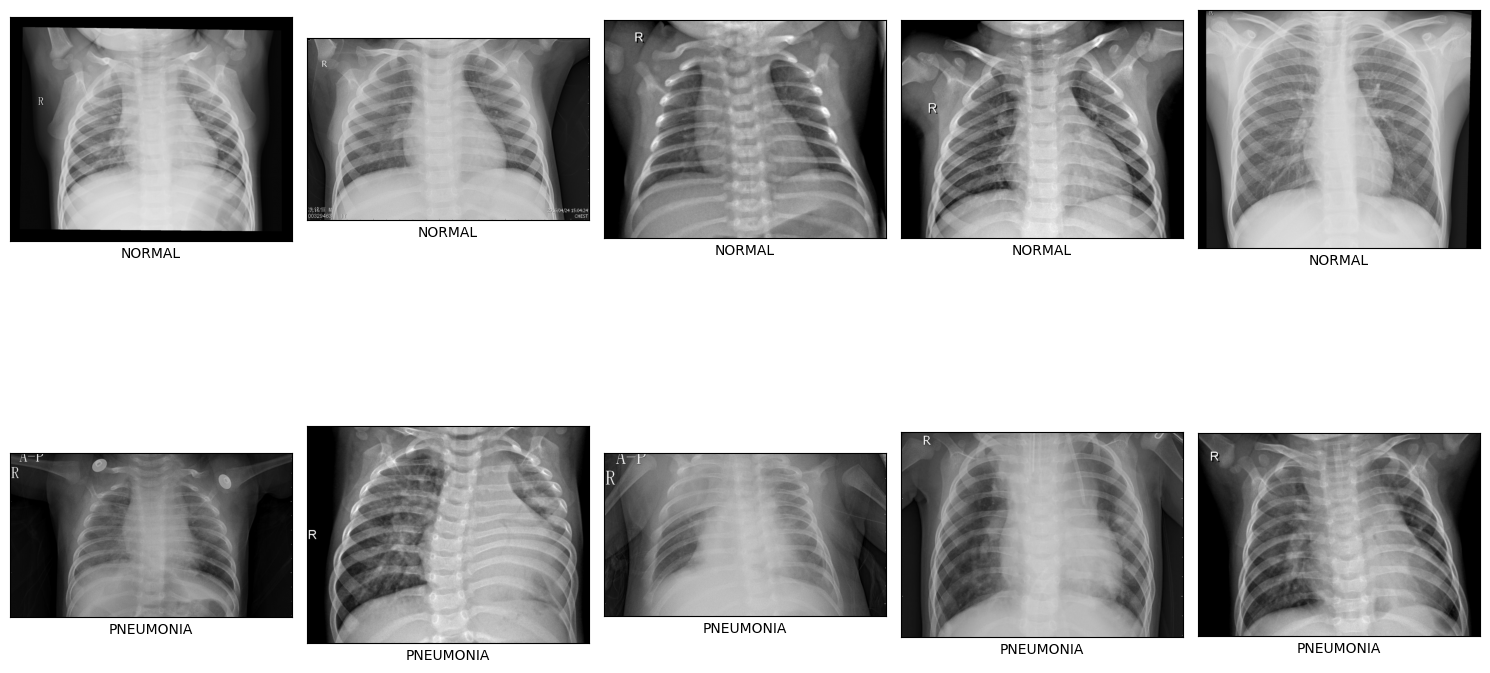

In [ ]:
import matplotlib.pyplot as plt
import os
import numpy as np
from PIL import Image

# 1. Pastikan path benar
path_sub = "chest_xray/dataset/"
lung_image = {}

# 2. Hanya ambil folder yang ADA isinya (mencegah error 'a' cannot be empty)
for i in os.listdir(path_sub):
    full_folder_path = os.path.join(path_sub, i)
    if os.path.isdir(full_folder_path):
        files = [f for f in os.listdir(full_folder_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
        if len(files) >= 5: # Hanya masukkan jika ada minimal 5 gambar
            lung_image[i] = files

# 3. Menampilkan gambar (Hanya jika lung_image tidak kosong)
if not lung_image:
    print("❌ Waduh, tidak ada gambar ditemukan di folder tersebut!")
else:
    classes = list(lung_image.keys())
    fig, axs = plt.subplots(len(classes), 5, figsize=(15, 10))

    # Jika hanya ada 1 kelas, axs akan berbentuk 1D, kita buat jadi 2D agar tidak error
    if len(classes) == 1:
        axs = np.expand_dims(axs, axis=0)

    for i, class_name in enumerate(classes):
        # Ambil 5 gambar acak dari list yang sudah kita filter tadi
        images = np.random.choice(lung_image[class_name], 5, replace=False)

        for j, image_name in enumerate(images):
            img_path = os.path.join(path_sub, class_name, image_name)
            img = Image.open(img_path).convert("L")
            axs[i, j].imshow(img, cmap='gray')
            axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])

    fig.tight_layout()
    plt.show()

**D. Plot Distribusi**

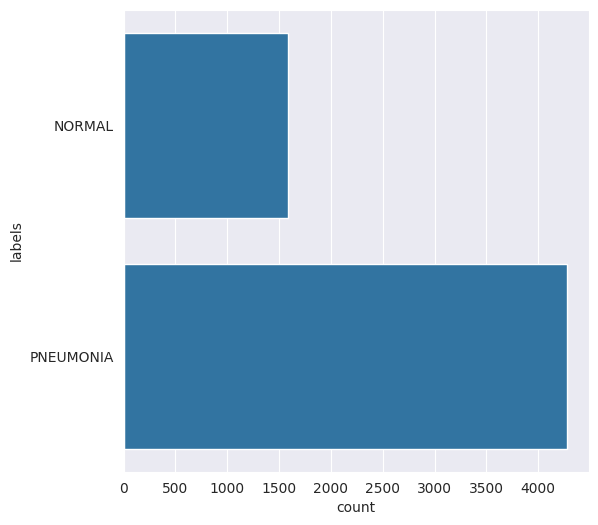

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Definisikan path sumber
lung_path = "chest_xray/dataset/"

# Buat daftar yang menyimpan data untuk setiap nama file, path file, dan label dalam data
file_name = []
labels = []
full_path = []

# Dapatkan nama file gambar, path file, dan label satu per satu dengan looping, dan simpan sebagai dataframe
for path, subdirs, files in os.walk(lung_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

distribution_train = pd.DataFrame({"path":full_path, 'file_name':file_name, "labels":labels})

# Plot distribusi gambar di setiap kelas
Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

**3. Data Augmentation**

  Proses augmentasi gambar adalah teknik yang digunakan dalam membuat variasi baru dari setiap gambar pada dataset sehingga model memiliki lebih banyak variasi untuk dipelajari. Ini membantu mencegah overfitting, yakni ketika model terlalu terbiasa dengan data pelatihan dan tidak dapat menggeneralisasi data baru dengan baik.

Berikut adalah beberapa strategi augmentasi gambar yang kita terapkan.

- anticlockwise_rotation adalah ketika gambar diputar ke arah berlawanan dengan jarum jam.
- clockwise_rotation adalah ketika gambar diputar searah dengan jarum jam.
- flip_up_down adalah ketika gambar dibalik secara vertikal dari atas ke bawah.
- sheared adalah ketika gambar diberikan efek pergeseran acak.
- blur adalah ketika gambar diberikan efek kabur atau blur.
- wrap_shift adalah ketika gambar diberikan efek pergeseran melengkung.
- brightness adalah ketika gambar diberikan efek peningkatan kecerahan.

In [ ]:
import os

# Gunakan path yang sudah ada di Colab kamu sekarang
# Jika tadi hasil unzip kamu masuk ke folder 'chest_xray', maka pakai ini:
asli_path = '/content/chest_xray/train/NORMAL'

# Cek apakah folder tersebut benar-benar ada
if os.path.exists(asli_path):
    print(f"✅ Mantap, folder sudah ada. Tidak perlu download lagi!")

    # Siapkan folder untuk hasil augmentasi
    aug_path = '/content/chest_xray/train/NORMAL_augmented'
    if not os.path.exists(aug_path):
        os.makedirs(aug_path)
        print(f"✅ Folder augmented siap di: {aug_path}")

    # Ambil daftar gambar
    images_normal = [os.path.join(asli_path, f) for f in os.listdir(asli_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
    print(f"✅ Ada {len(images_normal)} gambar asli. SIAP AUGMENTASI!")
else:
    print("❌ Folder NORMAL tidak ketemu di path tersebut. Cek lagi sidebar kiri kamu, Ahmad!")

✅ Mantap, folder sudah ada. Tidak perlu download lagi!
✅ Ada 1349 gambar asli. SIAP AUGMENTASI!


In [ ]:
import cv2
import numpy as np
from skimage.transform import rotate
from skimage.exposure import adjust_gamma
from skimage import img_as_ubyte, io

def augment_process(img):
    # 1. Resize ke 150x150 (WAJIB agar sesuai model kamu)
    img = cv2.resize(img, (150, 150))

    # 2. Pilih efek secara acak
    choice = np.random.choice(['rotate', 'flip', 'bright', 'blur'])

    if choice == 'rotate':
        img = rotate(img, angle=np.random.randint(-15, 15))
    elif choice == 'flip':
        img = np.fliplr(img)
    elif choice == 'bright':
        img = adjust_gamma(img, gamma=np.random.uniform(0.8, 1.2))
    else:
        img = cv2.GaussianBlur(img, (5, 5), 0)

    return img

In [ ]:
import random

total_target = 2000
count = 1

print("🚀 Memulai proses augmentasi...")
while count <= total_target:
    path_asal = random.choice(images_normal)
    try:
        img_raw = io.imread(path_asal)
        img_aug = augment_process(img_raw)

        # Simpan hasil
        nama_file = f"aug_{count}.jpg"
        path_simpan = os.path.join(aug_path, nama_file)

        # Pastikan dalam format uint8 untuk disimpan
        final_save = img_as_ubyte(img_aug)

        # Simpan sebagai BGR agar bisa dibaca OpenCV
        if len(final_save.shape) == 3:
            final_save = cv2.cvtColor(final_save, cv2.COLOR_RGB2BGR)

        cv2.imwrite(path_simpan, final_save)

        if count % 500 == 0:
            print(f"✅ Berhasil membuat {count} gambar...")
        count += 1
    except:
        continue

print(f"✨ SELESAI! Folder {aug_path} sekarang berisi 2000 gambar baru.")

🚀 Memulai proses augmentasi...
✅ Berhasil membuat 500 gambar...
✅ Berhasil membuat 1000 gambar...
✅ Berhasil membuat 1500 gambar...
✅ Berhasil membuat 2000 gambar...
✨ SELESAI! Folder /content/chest_xray/train/NORMAL_augmented sekarang berisi 2000 gambar baru.



--- DISTRIBUSI DATA AKHIR ---
labels
PNEUMONIA    3883
NORMAL       3349
Name: count, dtype: int64


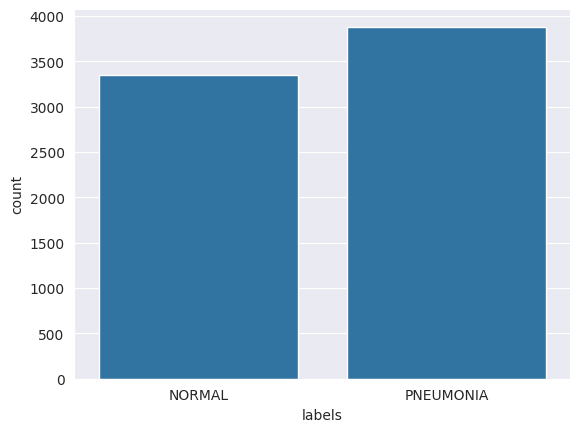

In [ ]:
import pandas as pd

paths = []
labels = []

# Kita scan folder 'train' yang tadi ketemu
parent_train = os.path.dirname(asli_path)

for folder in os.listdir(parent_train):
    folder_full_path = os.path.join(parent_train, folder)
    if os.path.isdir(folder_full_path):
        for file in os.listdir(folder_full_path):
            paths.append(os.path.join(folder_full_path, file))

            # Jika nama foldernya ada kata 'NORMAL', kasih label 'NORMAL'
            if 'NORMAL' in folder:
                labels.append('NORMAL')
            else:
                labels.append('PNEUMONIA')

df = pd.DataFrame({'path': paths, 'labels': labels})
print("\n--- DISTRIBUSI DATA AKHIR ---")
print(df['labels'].value_counts())

import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='labels', data=df)
plt.show()

**4. Data Spliting**

Setelah memastikan bahwa data telah seimbang, langkah selanjutnya adalah membagi data menjadi set pelatihan (training set) dan set pengujian (test set). Proses ini dikenal sebagai data splitting. Dengan membagi data ini, kita bisa melatih model pada set pelatihan dan menguji kinerjanya dalam set pengujian untuk memastikan bahwa model dapat digeneralisasi secara baik ke data baru yang tidak terlihat sebelumnya.

In [ ]:
# Panggil variabel mypath yang menampung folder dataset gambar
mypath= 'chest_xray/dataset/'

file_name = []
labels = []
full_path = []
for path, subdirs, files in os.walk(mypath):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

# Memasukkan variabel yang sudah dikumpulkan pada looping di atas menjadi sebuah dataframe agar rapi
df = pd.DataFrame({"path":full_path,'file_name':file_name,"labels":labels})
# Melihat jumlah data gambar pada masing-masing label
df.groupby(['labels']).size()


,0
labels,
NORMAL,1583
PNEUMONIA,4273


In [ ]:
# Variabel yang digunakan pada pemisahan data ini di mana variabel x = data path dan y = data labels

X= df['path']
y= df['labels']

# Split dataset awal menjadi data train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=300)

In [ ]:
# Menyatukan ke dalam masing-masing dataframe
df_tr = pd.DataFrame({'path':X_train,'labels':y_train,'set':'train'})
df_te = pd.DataFrame({'path':X_test,'labels':y_test,'set':'test'})

In [ ]:
# Gabungkan DataFrame df_tr dan df_te
df_all = pd.concat([df_tr, df_te], ignore_index=True)

print('===================================================== \n')
print(df_all.groupby(['set', 'labels']).size(), '\n')
print('===================================================== \n')

# Cek sampel data
print(df_all.sample(5))

# Memanggil dataset asli yang berisi keseluruhan data gambar yang sesuai dengan labelnya
datasource_path = "chest_xray/dataset/"
# Membuat variabel Dataset, tempat menampung data yang telah dilakukan pembagian data training dan testing
dataset_path = "Dataset-Final/"


set    labels   
test   NORMAL        334
       PNEUMONIA     838
train  NORMAL       1249
       PNEUMONIA    3435
dtype: int64 


                                                   path     labels    set
3673  chest_xray/dataset/PNEUMONIA/BACTERIA-2422671-...  PNEUMONIA  train
2455  chest_xray/dataset/NORMAL/NORMAL-4221981-0001....     NORMAL  train
4300  chest_xray/dataset/PNEUMONIA/BACTERIA-213622-0...  PNEUMONIA  train
1285  chest_xray/dataset/NORMAL/NORMAL-6112892-0001....     NORMAL  train
2371  chest_xray/dataset/PNEUMONIA/BACTERIA-5150733-...  PNEUMONIA  train


In [ ]:
for index, row in tq(df_all.iterrows()):
    # Deteksi filepath
    file_path = row['path']
    if os.path.exists(file_path) == False:
            file_path = os.path.join(datasource_path,row['labels'],row['image'].split('.')[0])

    # Buat direktori tujuan folder
    if os.path.exists(os.path.join(dataset_path,row['set'],row['labels'])) == False:
        os.makedirs(os.path.join(dataset_path,row['set'],row['labels']))

    # Tentukan tujuan file
    destination_file_name = file_path.split('/')[-1]
    file_dest = os.path.join(dataset_path,row['set'],row['labels'],destination_file_name)

    # Salin file dari sumber ke tujuan
    if os.path.exists(file_dest) == False:
        shutil.copy2(file_path,file_dest)

0it [00:00, ?it/s]

**5. Image Data Generator**

Image data generator adalah sebuah kelas di Keras yang digunakan untuk melakukan augmentasi dan pra-pemrosesan gambar secara otomatis selama pelatihan model. Selain itu, image data generator juga dapat membagi dataset menjadi set pelatihan dan validasi, serta normalisasi gambar dengan menskalakan nilai piksel. Dengan menggunakan generator ini, kita bisa memasukkan data gambar langsung ke model selama pelatihan, evaluasi, dan prediksi.

In [ ]:
# Definisikan direktori training dan test
TRAIN_DIR = "Dataset-Final/train/"
TEST_DIR = "Dataset-Final/test/"

train_normal = os.path.join(TRAIN_DIR + '/NORMAL')
train_pneumonia = os.path.join(TRAIN_DIR + '/PNEUMONIA')
test_normal = os.path.join(TEST_DIR + '/NORMAL')
test_pneumonia = os.path.join(TEST_DIR + '/PNEUMONIA')

print("Total number of normal images in training set: ",len(os.listdir(train_normal)))
print("Total number of pneumonic images in training set: ",len(os.listdir(train_pneumonia)))
print("Total number of normal images in test set: ",len(os.listdir(test_normal)))
print("Total number of pneumonic images in test set: ",len(os.listdir(test_pneumonia)))

Total number of normal images in training set:  1249
Total number of pneumonic images in training set:  3435
Total number of normal images in test set:  334
Total number of pneumonic images in test set:  838


In [ ]:
# Buat objek ImageDataGenerator yang menormalkan gambar
datagen = ImageDataGenerator(rescale=1/255.,
                             validation_split = 0.2)
test_datagen = ImageDataGenerator(rescale=1. / 255)

train_generator = datagen.flow_from_directory(TRAIN_DIR,
                                              batch_size=32,
                                              target_size=(150,150),
                                              color_mode="grayscale",
                                              class_mode='binary',
                                              subset='training',
                                              shuffle=True)

validation_generator = datagen.flow_from_directory(TRAIN_DIR,
                                                   batch_size=32,
                                                   target_size=(150,150),
                                                color_mode="grayscale",
                                                   class_mode='binary',
                                                   subset='validation',
                                                   shuffle=False)

test_generator = test_datagen.flow_from_directory(TEST_DIR,
                                                  batch_size=1,
                                                  target_size=(150,150),
                                                  color_mode="grayscale",
                                                  class_mode='binary',
                                                  shuffle=False)

Found 3748 images belonging to 2 classes.
Found 936 images belonging to 2 classes.
Found 1172 images belonging to 2 classes.


**6. Pembangunan Model dengan Beberapa Skema Parameter Tuning**

a. Skema CNN Architecture dengan 32 Neurons pada Conv Layer

In [ ]:
# tf.keras.backend.clear_session()

####################### Init sequential model ##################################
model_1 = Sequential()

# ######################### Input layer with Fully Connected Layer ################################
# 1st Convolutional layer, Batch Normalization layer, and Pooling layer
model_1.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(150,150,1)))
model_1.add(BatchNormalization())
model_1.add(MaxPool2D((2, 2)))

# 2nd Convolutional layer, Batch Normalization layer, and Pooling layer
model_1.add(Conv2D(32, (4, 4),padding='same', activation='relu'))
model_1.add(BatchNormalization())
model_1.add(MaxPool2D((2, 2)))

# 3rd Convolutional layer, Batch Normalization layer, and Pooling layer
model_1.add(Conv2D(32, (7, 7), padding='same', activation='relu'))
model_1.add(BatchNormalization())
model_1.add(MaxPool2D((2, 2)))

# Flatten layer
model_1.add(Flatten())
# 1nd Dense Layer
model_1.add(Dense(128, activation = 'relu'))
# 1nd Dropout Layer
model_1.add(Dropout(0.5))
# 2nd Dense Layer
model_1.add(Dense(64, activation = 'relu'))
# 2nd Dropout Layer
model_1.add(Dropout(0.3))

# Final Dense layer => For output prediction 1 mean (binary class in dataset), sigmoid for binary cases
model_1.add(Dense(1, activation='sigmoid'))
######################### Fully Connected Layer ################################

######################### Compile Model ################################
model_1.compile(optimizer=tf.keras.optimizers.RMSprop(),
                loss='binary_crossentropy',
                metrics=['accuracy'])

# Summary of the Model Architecture
print(model_1.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 75, 75, 32)     │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 75, 75, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 32)     │        50,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 37, 37, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,327,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,402,881 (5.35 MB)

 Trainable params: 1,402,689 (5.35 MB)

 Non-trainable params: 192 (768.00 B)

None


In [ ]:
count_normal, count_pneumonia = len(os.listdir(train_normal)), len(os.listdir(train_pneumonia))
weight_0 = (1 / count_normal) * (count_normal + count_pneumonia) / 2.0
weight_1 = (1 / count_pneumonia) * (count_pneumonia + count_normal) / 2.0

class_weights = {0 : weight_0, 1 : weight_1}

%time

# Fitting / training model
history_1 = model_1.fit(train_generator,
                        epochs=30,
                        batch_size=32,
                        validation_data=validation_generator,
                        class_weight = class_weights)

CPU times: user 3 µs, sys: 1 µs, total: 4 µs
Wall time: 7.15 µs
Epoch 1/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 309s 3s/step - accuracy: 0.8279 - loss: 0.7782 - val_accuracy: 0.7340 - val_loss: 6.7304
Epoch 2/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 308s 3s/step - accuracy: 0.9082 - loss: 0.3992 - val_accuracy: 0.7340 - val_loss: 14.5883
Epoch 3/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 299s 3s/step - accuracy: 0.9232 - loss: 0.2962 - val_accuracy: 0.7340 - val_loss: 14.8062
Epoch 4/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 310s 3s/step - accuracy: 0.9333 - loss: 0.2376 - val_accuracy: 0.7340 - val_loss: 9.2435
Epoch 5/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 302s 3s/step - accuracy: 0.9424 - loss: 0.1941 - val_accuracy: 0.8782 - val_loss: 0.6775
Epoch 6/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 312s 3s/step - accuracy: 0.9456 - loss: 0.1783 - val_accuracy: 0.9156 - val_loss: 0.3386
Epoch 7/30
118/118 ━━━━━━━━━━━━━━━━━━━━ 300s 3s/step - accuracy: 0.9541 - loss: 0.1502 - val_accuracy: 0.9231 - val_loss: 0.6022
Epoch 8/30
118/118 ━━━━━━━━━━━━

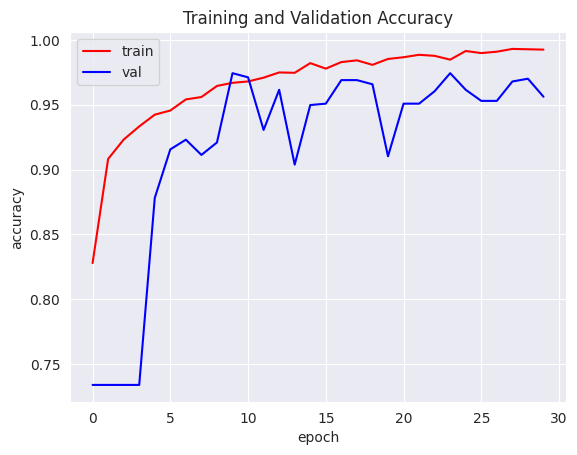

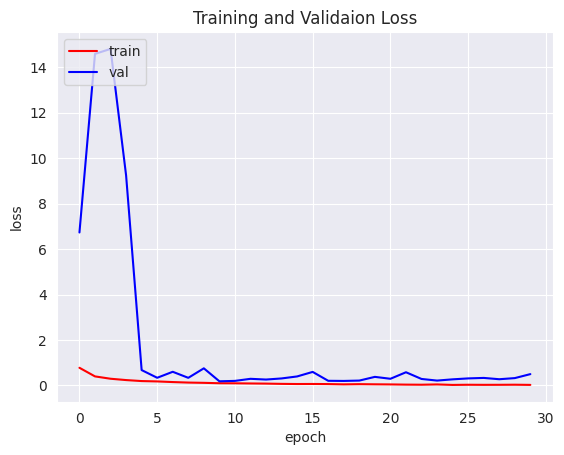

In [ ]:
acc = history_1.history['accuracy']
val_acc = history_1.history['val_accuracy']
loss = history_1.history['loss']
val_loss = history_1.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validaion Loss')
plt.show()



              precision    recall  f1-score   support

      Normal     0.9195    0.9581    0.9384       334
   Pneumonia     0.9830    0.9666    0.9747       838

    accuracy                         0.9642      1172
   macro avg     0.9513    0.9623    0.9566      1172
weighted avg     0.9649    0.9642    0.9644      1172



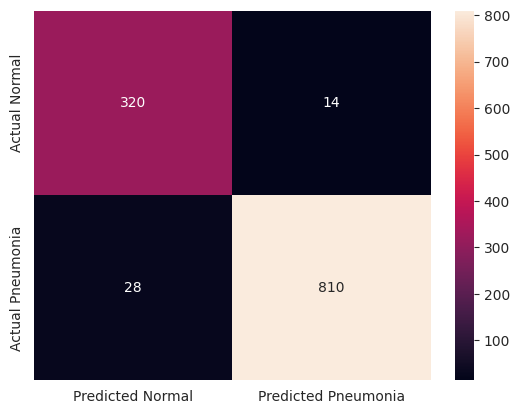

In [ ]:
test_generator.reset()

preds_1 = model_1.predict(test_generator,verbose=0)
preds_1 = preds_1.copy()
preds_1[preds_1 <= 0.5] = 0
preds_1[preds_1 > 0.5] = 1

# Print Confusion Matrix
cm = pd.DataFrame(data=confusion_matrix(test_generator.classes, preds_1, labels=[0, 1]),index=["Actual Normal", "Actual Pneumonia"],
columns=["Predicted Normal", "Predicted Pneumonia"])
sns.heatmap(cm,annot=True,fmt="d")

# Print Classification Report
print("\n")
print(classification_report(y_true=test_generator.classes,y_pred=preds_1,target_names =['Normal','Pneumonia'], digits=4))

In [ ]:
model_1.save('model_pneumonia_v1.h5')